In [1]:
import tensorflow as tf

In [2]:
print(tf.__version__)

2.9.2


# Load in the data

In [3]:
# Split into train and test
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


# Normalize values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

x_train.shape

(60000, 28, 28)

In [4]:
# Validation set
x_train, x_valid = x_train[:55_000], x_train[55_000:]
y_train, y_valid = y_train[:55_000], y_train[55_000:]

# Build the model

In [5]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Learning rate scheduling

In [6]:
import math
batch_size = 32
n_epochs = 15

n_steps = n_epochs * math.ceil(len(x_train) / batch_size)
scheduled_learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
initial_learning_rate=0.001, decay_steps=n_steps, decay_rate=0.01)

optimizer = tf.keras.optimizers.Adam(learning_rate=scheduled_learning_rate)

# Compile the model

In [7]:
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#Set callbacks for saving best model so far and early stopping

In [8]:
checkpoint_filepath = 'my_checkpoint'

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, save_best_only=True, save_weights_only=True,)

# early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10,
# restore_best_weights=True)

# Train model
- Using Callbacks to set checkpoints of best model on the validation set

In [9]:
r = model.fit(x_train, y_train, validation_data=(x_valid, y_valid), epochs=15, callbacks=[checkpoint_cb])

Epoch 1/15
1719/1719 [==============================] - 17s 9ms/step - loss: 0.3034 - accuracy: 0.9082 - val_loss: 0.1064 - val_accuracy: 0.9690
Epoch 2/15
1719/1719 [==============================] - 7s 4ms/step - loss: 0.1402 - accuracy: 0.9577 - val_loss: 0.0779 - val_accuracy: 0.9758
Epoch 3/15
1719/1719 [==============================] - 8s 4ms/step - loss: 0.1008 - accuracy: 0.9685 - val_loss: 0.0761 - val_accuracy: 0.9778
Epoch 4/15
1719/1719 [==============================] - 8s 4ms/step - loss: 0.0788 - accuracy: 0.9756 - val_loss: 0.0707 - val_accuracy: 0.9798
Epoch 5/15
1719/1719 [==============================] - 7s 4ms/step - loss: 0.0669 - accuracy: 0.9792 - val_loss: 0.0676 - val_accuracy: 0.9816
Epoch 6/15
1719/1719 [==============================] - 7s 4ms/step - loss: 0.0584 - accuracy: 0.9815 - val_loss: 0.0663 - val_accuracy: 0.9826
Epoch 7/15
1719/1719 [==============================] - 7s 4ms/step - loss: 0.0522 - accuracy: 0.9839 - val_loss: 0.0674 - val_accuracy

In [10]:
# The model weights (that are considered the best) are loaded into the model.
model.load_weights(checkpoint_filepath)

In [11]:
import matplotlib.pyplot as plt

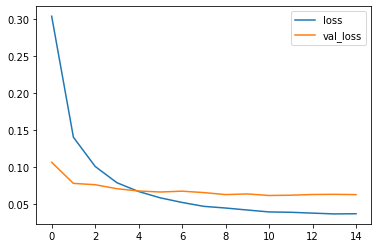

In [12]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend();

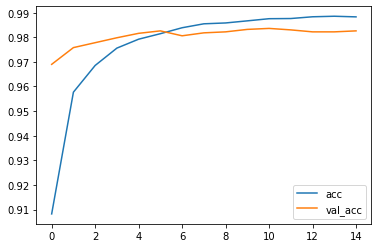

In [13]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend();

In [14]:
print(model.evaluate(x_valid, y_valid))

157/157 [==============================] - 1s 4ms/step - loss: 0.0616 - accuracy: 0.9836
[0.06157242879271507, 0.9836000204086304]


In [15]:
print(model.evaluate(x_test, y_test))

313/313 [==============================] - 1s 4ms/step - loss: 0.0652 - accuracy: 0.9811
[0.06524170935153961, 0.9811000227928162]


313/313 [==============================] - 1s 2ms/step
Confusion matrix, without normalization


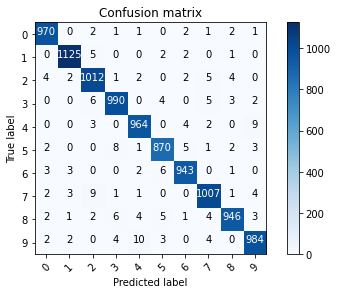

In [16]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  """
  This function prints and plots the confusion matrix.
  Normalization can be applied by setting `normalize=True`.
  """
  if normalize:
      cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
      print("Normalized confusion matrix")
  else:
      print('Confusion matrix, without normalization')

 # print(cm)

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, format(cm[i, j], fmt),
               horizontalalignment="center",
               color="white" if cm[i, j] > thresh else "black")

  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.show()


p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

# Do these results make sense?
# It's easy to confuse 9 <--> 4, 9 <--> 7, 2 <--> 7, etc. 

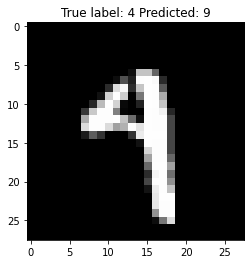

In [17]:
# Show some misclassified examples
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i], cmap='gray')
plt.title("True label: %s Predicted: %s" % (y_test[i], p_test[i]));

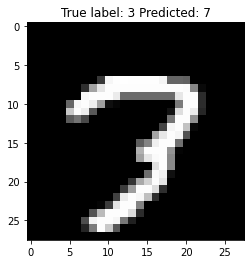

In [18]:
# Show some misclassified examples
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i], cmap='gray')
plt.title("True label: %s Predicted: %s" % (y_test[i], p_test[i]));